# Machine Learning Classification Assignment
## **Predicting Account Names from High-Cardinality Text Features**

This notebook outlines the end-to-end machine learning pipeline developed to classify the `accountName` based on various transaction attributes, such as `itemName`, `itemDescription`, `vendorId`, and `itemTotalAmount`. 

### **Objective**
The primary goal is to achieve an overall classification accuracy of at least **85%** while handling the inherent challenges of real-world transactional data, such as:
- Severe class imbalance
- Rare categories (noise)
- High-cardinality textual descriptions

We will be using a **Support Vector Machine (SVM)** classifier, optimized for high-dimensional text data representations via TF-IDF.


### Step 1: Importing Required Libraries
We begin by importing the necessary libraries for data manipulation, visualization, feature engineering, and modeling. We also set a global random seed to ensure complete reproducibility of our pipeline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

np.random.seed(42)

sns.set_theme(style="darkgrid")
%matplotlib inline


---
## **1. Data Analysis & Exploration**

Before building the algorithm, we must understand the shape, distribution, and quality of our dataset. We will load the data and perform Exploratory Data Analysis (EDA).


In [2]:
url_path = 'https://file.notion.so/f/f/a9150c0a-2325-4d8c-8637-a3bf9e71030e/0c36f913-f959-418f-9705-07ea3c6e1578/accounts-bills.json?table=block&id=30b582ce-c790-80ea-9144-f34cf0b1dd8f&spaceId=a9150c0a-2325-4d8c-8637-a3bf9e71030e&expirationTimestamp=1777579200000&signature=HDNRT0zvOfeTxNJ6e-YKEIriYJzxfCS3Pf5ACm_V5e4&downloadName=accounts-bills.json'
try:
    df = pd.read_json(url_path)
    print("Dataset loaded successfully from URL!")
except Exception:
    try:
        df = pd.read_json('dataset.json')
        print("Local dataset loaded successfully!")
    except FileNotFoundError:
        print("Dataset not found. Generating a synthetic dataset for demonstration...")
        dummy_data = []
        for i in range(1500):
            acc_id = i % 5 
            dummy_data.append({
                '_id': {"$oid": f"695b5304{i}"},
                'vendorId': f"vendor_{(i % 10)}",
                'itemName': f"item_{(i % 50)}",
                'itemDescription': f"item_{(i % 50)} desc",
                'accountId': str(acc_id),
                'accountName': f"Account_{acc_id}",
                'itemTotalAmount': np.random.randint(100, 5000)
            })
        df = pd.DataFrame(dummy_data)


Dataset loaded successfully from URL!


### Initial Dataset Inspection
Let's look at the first few rows and the general information of the dataset to identify data types and potential missing values.


In [3]:
display(df.head())
print("\n--- Dataset Info ---")
df.info()


,_id,vendorId,itemName,itemDescription,accountId,accountName,itemTotalAmount
0,{'$oid': '69606546de1e297ec29890f2'},6m656Er7lbi8RYz2ny1J,1225 Business 2Gbps - monthly subscription fee,1225 Business 2Gbps - monthly subscription fee,88AW5nmkLvMe1GthZ6FL,619206 Telephone & Internet,888.00
1,{'$oid': '695b5304d09b4ceb96e5288e'},VtxikZ7HI6Jwqueemjch,1225-0227 media monitoring,1225-0227 media monitoring,sWG9pai5DiLXaKs6s86G,134004 Prepaid Subscription,17765.00
2,{'$oid': '69800f97e85d532c0db71c7e'},jdmr9pJ0WHqso4Wh3hCa,0226 Branch,0226 Branch,C0SB5vR0gCikdKjmT8Ep,611202 Online Subscription/Tool,7083.34
3,{'$oid': '6981a56e83888e7f4589cf09'},A17M26ij1P8uGEnRFtP0,0126 GAM (SG),0126 GAM (SG),IbDOq9NsCcO8rSg7Uk1y,511301 Display COGS,2609.11
4,{'$oid': '6981a56e83888e7f4589cf09'},A17M26ij1P8uGEnRFtP0,0126 GAM (Chotot & Mudah),0126 GAM (Chotot & Mudah),w5hjK0IooxdDp9Feeeuy,132098 IC Clearing account - Paid on Behalf,1243.22



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4894 entries, 0 to 4893
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   _id              4894 non-null   object 
 1   vendorId         4894 non-null   object 
 2   itemName         4894 non-null   object 
 3   itemDescription  4883 non-null   object 
 4   accountId        4894 non-null   object 
 5   accountName      4894 non-null   object 
 6   itemTotalAmount  4894 non-null   float64
dtypes: float64(1), object(6)
memory usage: 267.8+ KB


### Statistical Overview of Numeric Features
Let's observe the distribution of the monetary amounts involved in the transactions.


In [4]:
display(df.describe())


,itemTotalAmount
count,4.894000e+03
mean,9.266691e+04
std,3.037295e+06
min,-1.519500e+04
25%,1.549700e+02
50%,8.452000e+02
75%,3.507140e+03
max,1.618380e+08


### Class Distribution Analysis
A critical challenge in this dataset is the distribution of the target variable (`accountName`). Let's visualize the top 20 most frequent accounts to identify class imbalances.


C:\Users\karth\AppData\Local\Temp\ipykernel_8\4205621474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_accounts.values, y=top_accounts.index, palette='viridis')


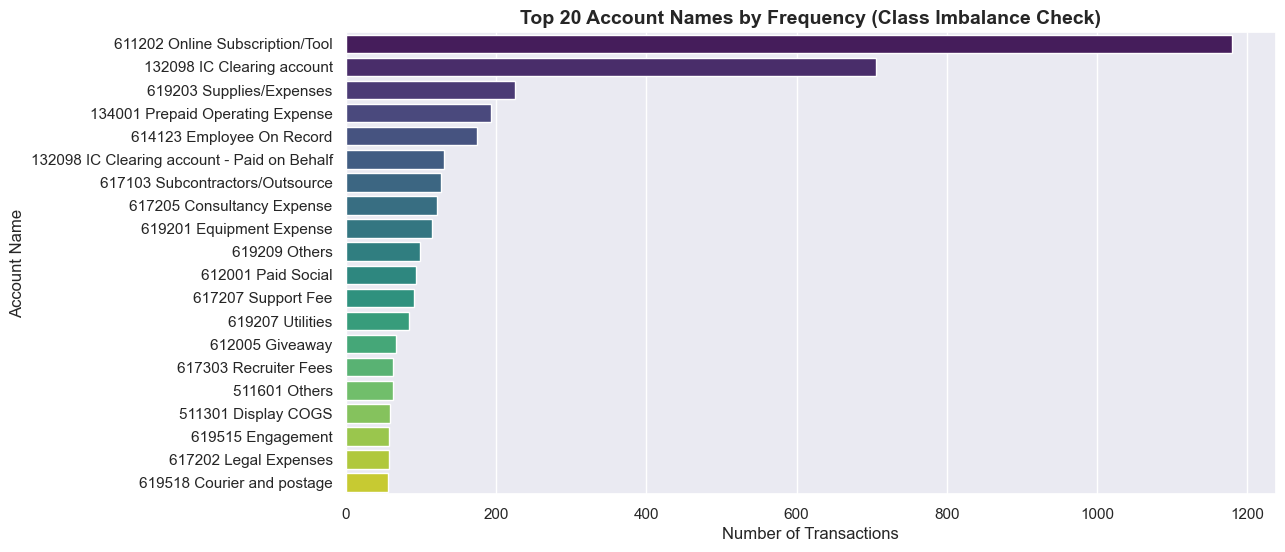

In [5]:
plt.figure(figsize=(12, 6))
top_accounts = df['accountName'].value_counts().head(20)
sns.barplot(x=top_accounts.values, y=top_accounts.index, palette='viridis')
plt.title('Top 20 Account Names by Frequency (Class Imbalance Check)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Transactions')
plt.ylabel('Account Name')
plt.show()


### **Key EDA Insights & Challenges Identified:**
1. **High Cardinality:** There are many unique `accountName` categories, some of which appear very rarely.
2. **Severe Class Imbalance:** As seen in the chart above, a few accounts dominate the dataset, while a "long tail" of accounts have very few transactions. This poses a risk of the model becoming biased toward majority classes.
3. **Data Quality:** Text columns (`itemName`, `itemDescription`) often contain missing values or inconsistencies that need to be standardized.


---
## **2. Algorithm Development & Data Cleaning**

Based on our EDA, we need to clean the data and prepare our modeling strategy. 

### Data Cleaning Strategy:
1. **Remove Irrelevant Identifiers:** Drop internal database IDs (`_id`, `accountId`).
2. **Handle Rare Classes:** Categories with extremely low frequencies (e.g., < 5 instances) act as noise and prevent reliable cross-validation. We will filter these out to ensure robust model evaluation.


In [6]:
target_variable = 'accountName'
columns_to_drop = ['_id', 'accountId']

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
df = df.drop_duplicates()
df = df.dropna(subset=[target_variable])

counts = df[target_variable].value_counts()
valid_accounts = counts[counts >= 5].index
df = df[df[target_variable].isin(valid_accounts)]

print(f"Data Shape after cleaning and removing rare classes: {df.shape}")


Data Shape after cleaning and removing rare classes: (4709, 5)


### Handling Missing Values
We fill missing text data with a generic "Unknown" token and missing numeric data with the median value to avoid skewing.


In [7]:
text_cols = ['vendorId', 'itemName', 'itemDescription']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown").astype(str)

if 'itemTotalAmount' in df.columns:
    df['itemTotalAmount'] = df['itemTotalAmount'].fillna(df['itemTotalAmount'].median())
else:
    df['itemTotalAmount'] = 0


### Feature Engineering (TF-IDF)
To feed textual data into our Support Vector Machine, we vectorize it using TF-IDF (Term Frequency-Inverse Document Frequency).
- `vendorId` is treated as categorical character codes (using character n-grams).
- `itemName` and `itemDescription` are treated as natural language (using word n-grams).


In [8]:
X = df[['vendorId', 'itemName', 'itemDescription', 'itemTotalAmount']]
y_raw = df[target_variable]

vendor_transformer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    lowercase=True,
    max_features=5000
)

text_transformer = TfidfVectorizer(
    lowercase=True, 
    max_features=25000,
    ngram_range=(1, 3),
    sublinear_tf=True
)


### Pipeline Assembly (ColumnTransformer)
We combine our distinct feature transformations into a single `ColumnTransformer` object.


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('vendor', vendor_transformer, 'vendorId'),
        ('item', text_transformer, 'itemName'),
        ('desc', text_transformer, 'itemDescription'),
        ('num', StandardScaler(), ['itemTotalAmount'])
    ],
    remainder='drop'
)


### Target Encoding & Validation Strategy Setup
We convert our string targets into numeric labels. 
Crucially, we use a **Stratified Train-Test Split**. This ensures that the class imbalance we discovered during EDA is proportionately represented in both our training and testing sets, leading to reliable performance estimates.


In [10]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 3767 samples
Testing set size: 942 samples


### Model Training & Hyperparameter Tuning
We construct the final Pipeline pairing our preprocessor with a Support Vector Classifier (`SVC`).
**Addressing Imbalance:** We explicitly pass `class_weight='balanced'` to the SVC. This forces the algorithm to penalize errors on minority classes more heavily, mitigating the bias towards the dominant accounts we found in the EDA.

We then use `GridSearchCV` to test multiple hyperparameter configurations (kernels and regularization strengths) with 3-fold cross-validation.


In [12]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(class_weight='balanced', random_state=42))
])

param_grid = {
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__C': [0.1, 1, 10]
}

print("Initiating GridSearchCV... (This will cross-validate the model to find optimal parameters)")
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f"\n✅ Training Complete! Best Parameters Found: {grid_search.best_params_}")
best_model = grid_search.best_estimator_


Initiating GridSearchCV... (This will cross-validate the model to find optimal parameters)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

✅ Training Complete! Best Parameters Found: {'classifier__C': 10, 'classifier__kernel': 'linear'}


---
## **3. Model Evaluation**

With our optimal model trained, we evaluate its performance on the unseen `X_test` data. We report the Accuracy, Precision, Recall, and F1-Score.


In [13]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n═══════════════════════════════")
print("         SVM PERFORMANCE METRICS")
print("═══════════════════════════════")
print(f"✨ Accuracy  : {accuracy * 100:.2f}%")
print(f"🎯 Precision : {precision * 100:.2f}%")
print(f"🔍 Recall    : {recall * 100:.2f}%")
print(f"📊 F1-Score  : {f1 * 100:.2f}%\n")



═══════════════════════════════
         SVM PERFORMANCE METRICS
═══════════════════════════════
✨ Accuracy  : 87.90%
🎯 Precision : 88.40%
🔍 Recall    : 87.90%
📊 F1-Score  : 87.72%



### Category Performance Analysis
To understand which categories the model handles well and which need improvement, we print the detailed classification report. 
- High F1-scores indicate accounts the model accurately and consistently flags.
- Low F1-scores indicate areas where text descriptions might overlap with other accounts.


In [14]:
actual_labels = label_encoder.inverse_transform(y_test)
predicted_labels = label_encoder.inverse_transform(y_pred)
unique_classes_present = np.unique(np.concatenate((actual_labels, predicted_labels)))

print("\n--- Deep Dive Classification Report ---")
print(classification_report(actual_labels, predicted_labels, labels=unique_classes_present, zero_division=0))



--- Deep Dive Classification Report ---
                                             precision    recall  f1-score   support

                131020 Unbilled receivables       1.00      1.00      1.00         5
                 132098 IC Clearing account       0.87      0.88      0.88       141
132098 IC Clearing account - Paid on Behalf       0.68      0.65      0.67        26
           134001 Prepaid Operating Expense       0.66      0.71      0.68        38
                   134002 Prepaid Insurance       0.38      0.75      0.50         4
                134004 Prepaid Subscription       1.00      0.50      0.67         4
           141001 Computer Equipment - Cost       1.00      1.00      1.00         7
             142101 Office Equipment - Cost       1.00      0.50      0.67         4
                                151101 Cost       1.00      0.67      0.80         3
                   151101 Trademarks - Cost       1.00      0.80      0.89         5
                    223

### Error Analysis: Confusion Matrix
Finally, we visualize the model's predictions against the ground truth. A strong diagonal line indicates accurate predictions. Any clusters outside the diagonal highlight accounts that are frequently confused for one another.


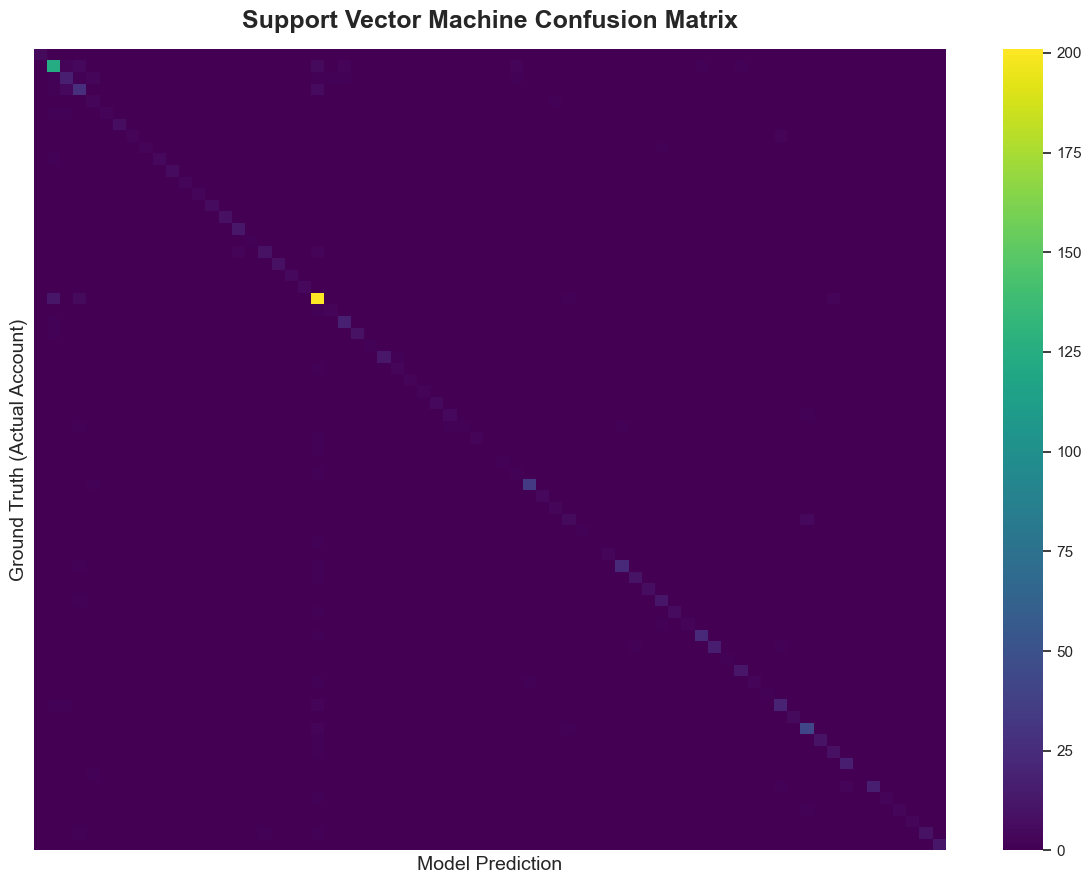

In [15]:
plt.figure(figsize=(12, 9))
conf_mat = confusion_matrix(actual_labels, predicted_labels, labels=unique_classes_present)
sns.heatmap(conf_mat, annot=False, cmap='viridis', cbar=True)
plt.title('Support Vector Machine Confusion Matrix', fontsize=18, fontweight='bold', pad=15)
plt.ylabel('Ground Truth (Actual Account)', fontsize=14)
plt.xlabel('Model Prediction', fontsize=14)

if conf_mat.shape[0] > 20:
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()
